# Rep. 4. Checkpoint 5. Exóticas: Asiáticas y con Barrera

## Opciones Asiaticas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
S0= 670
K=680
r=0.04
sigma=0.17
N=30 # numero de dias
T=N/365 # tiempo al venc
M = 10000 # numero de simulaciones
dt=T/N

Z =np.random.standard_normal((M,N)) # Generar números aleatorios
log_returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
S_paths= S0 * np.exp(np.cumsum(log_returns, axis=1)) # Simular precios
S_paths = np.insert(S_paths, 0, S0, axis=1) # Agregar el precio inicial

ST = S_paths[:,-1] # Precio al vencimiento

S_media= np.mean(S_paths, axis=1) # Precio promedio

payoffs = np.maximum(ST - K, 0) # Calcular los payoffs

europea = np.exp(-r * T) * np.maximum(ST - K, 0) # Valor de la opción europea

asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0) # Valor de la opción asiática

#black-scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print(f"Valor de la opción europea: {europea.mean():.2f}")
print(f"Valor de la opción asiática: {asiatica.mean():.2f}")
print(f"Valor de la opción black-scholes: {bs_price:.2f}")

Valor de la opción europea: 9.61
Valor de la opción asiática: 3.86
Valor de la opción black-scholes: 9.58


### Graficar

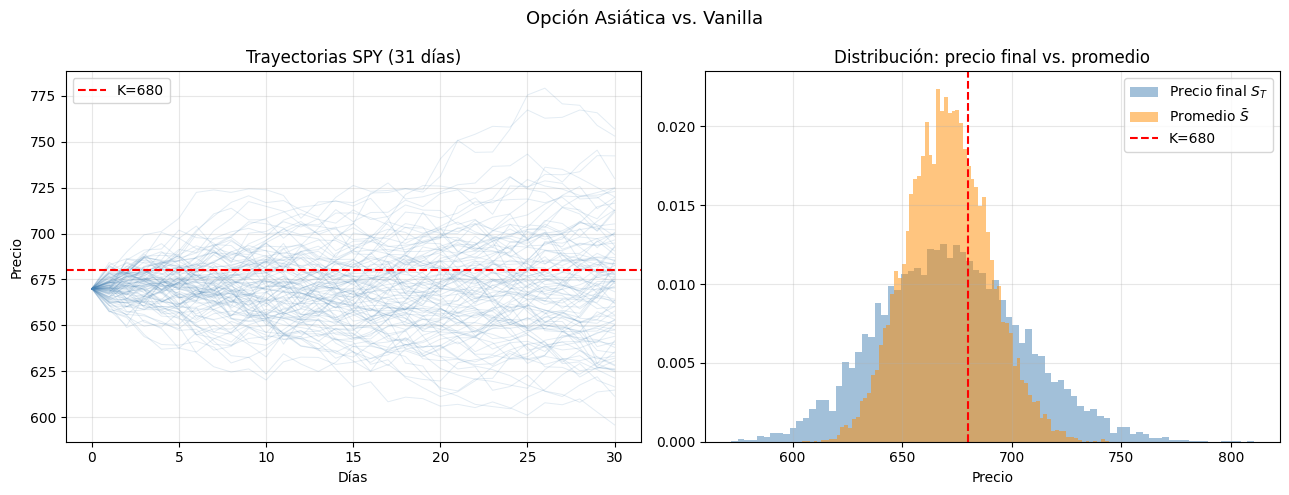

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias con el promedio marcado
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias SPY (31 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue', label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

## Opciones con barrera

In [15]:
B_up = 710

S_max = S_paths.max(axis=1)
print(S_max)

# up and out
activa_up_and_out = S_max < B_up
call_up_and_out = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# up and in
activa_up_and_in = S_max > B_up
call_up_and_in = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print(f"Valor de la opción up and out: {call_up_and_out.mean():.2f}")
print(f"Valor de la opción up and in: {call_up_and_in.mean():.2f}")
print(f"Valor de la opción europea: {europea.mean():.2f}")
print(f'comprobación: up and out + up and in = europea: {call_up_and_out.mean() + call_up_and_in.mean():.2f}')

[671.34246198 670.         693.66124223 ... 681.7928249  720.74760724
 701.17598165]
Valor de la opción up and out: 2.36
Valor de la opción up and in: 7.23
Valor de la opción europea: 9.58
comprobación: up and out + up and in = europea: 9.58


### Graficar

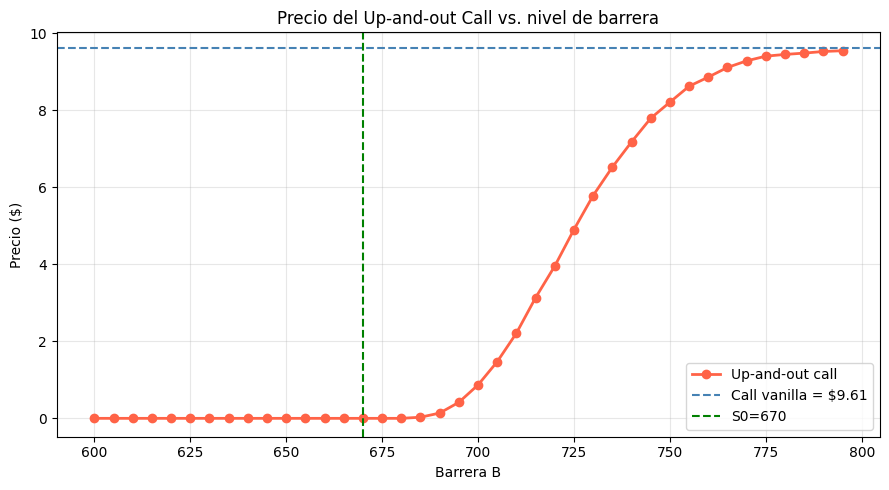

In [4]:
B_range = np.arange(600, 800, 5)   # barreras superiores
precios_uao = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precios_uao.append(precio.mean())

plt.figure(figsize=(9, 5))
plt.plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o',
         label='Up-and-out call')
plt.axhline(europea.mean(), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Call vanilla = ${europea.mean():.2f}')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Barrera B')
plt.ylabel('Precio ($)')
plt.title('Precio del Up-and-out Call vs. nivel de barrera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preguntas

- **La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?**

    Si la opcion asiatica es mas barata que la europa. Si la volatilidad fuera cero, podrian valer lo mismo. Seguiría una trayectoria determinista (creciendo a la tasa libre de riesgo). En este caso, el promedio y el valor final serían predecibles y las opciones tendrían el mismo valor

- **Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?**

    Que no deberia de haber arbitraje. Es extremadamente útil porque, a menudo, es analíticamente más sencillo calcular el precio de una opción Out. Una vez que tienes el precio de la Out y el de la europa, puedes obtener la in por simple sustracción
- **Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?**

    Si la barrera está muy cerca del precio inicial, existe una probabilidad altísima de que cualquier movimiento aleatorio al alza (por pequeño que sea) toque la barrera y "mate" la opción. Si la barrera se coloca a un nivel de precio que es estadísticamente improbable de alcanzar, la cláusula de "Out" se vuelve irrelevante y practicamente tienes una opcion europea.

- **¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?**
    
    La dependencia de la trayectoria es una de las razones principale, porque a diferencia de las opciones europeas las acciones exoticas si dependen de su trayectoria(ejemplo: si el precio de una opcion de barrera pasa su barrera se apaga). Su limitacion principal es que para que tenga un error decente necesitas hacer muchas simulaciones, por lo que tiene un costo computacional alto y toma tiempo, cosa que no pasa con soluciones analticas, ya que no tienen un alto costo computacional y el calculo es mucho mas rapido.
